In [63]:
# ============================================
# PROJECT 1: CREDIT RISK SCORECARD SYSTEM
# Nigerian Banking Context
# ============================================

# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("All libraries imported successfully!")

All libraries imported successfully!


In [64]:
# --- Load Dataset ---
df = pd.read_csv('../data/cs-training.csv')

# First look at the data
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (150000, 12)

First 5 rows:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


In [65]:
# --- Understand the Dataset ---
print("Column Names & Data Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Column Names & Data Types:
Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
                                         ...   
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
Length: 12, dtype: object

Basic Statistics:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [66]:
# --- Check Missing Values ---
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
})

print(missing_table[missing_table['Missing Values'] > 0])

Missing Values per Column:
                    Missing Values  Percentage (%)
MonthlyIncome                29731           19.82
NumberOfDependents            3924            2.62


In [67]:
# Fill MonthlyIncome with median
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'].fillna(median_income, inplace=True)

# Fill NumberOfDependents with median
median_dependents = df['NumberOfDependents'].median()
df['NumberOfDependents'].fillna(median_dependents, inplace=True)

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
33655


C:\Users\user\AppData\Local\Temp\ipykernel_19460\2868536950.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['MonthlyIncome'].fillna(median_income, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_19460\2868536950.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assig

In [68]:
# Fill MonthlyIncome with median
median_income = df['MonthlyIncome'].median()
df = df.assign(MonthlyIncome=df['MonthlyIncome'].fillna(median_income))

# Fill NumberOfDependents with median
median_dependents = df['NumberOfDependents'].median()
df = df.assign(NumberOfDependents=df['NumberOfDependents'].fillna(median_dependents))

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [69]:
# --- Handle Outliers ---

# Cap RevolvingUtilization between 0 and 1
df = df.assign(RevolvingUtilizationOfUnsecuredLines=df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1))

# Cap DebtRatio at 99th percentile
debt_cap = df['DebtRatio'].quantile(0.99)
df = df.assign(DebtRatio=df['DebtRatio'].clip(0, debt_cap))

# Remove unrealistic ages (below 18 and above 100)
df = df[(df['age'] >= 18) & (df['age'] <= 100)]

# Confirm results
print("Outliers handled successfully!")
print("Remaining records:", len(df))

Outliers handled successfully!
Remaining records: 149986


In [70]:
# --- Localize Dataset to Nigerian Banking Context ---

# Rename Unnamed: 0 to proper Customer ID
df = df.rename(columns={'Unnamed: 0': 'CustomerID'})

# Format CustomerID as Nigerian bank style
df['CustomerID'] = df['CustomerID'].apply(lambda x: f'CUS-{x:05d}')

# Confirm
print("Sample Customer IDs:")
print(df['CustomerID'].head())

Sample Customer IDs:
0    CUS-00001
1    CUS-00002
2    CUS-00003
3    CUS-00004
4    CUS-00005
Name: CustomerID, dtype: str


In [71]:
# --- Rename Columns to Banking Context ---

df = df.rename(columns={
    'SeriousDlqin2yrs': 'DefaultStatus',
    'RevolvingUtilizationOfUnsecuredLines': 'CreditUtilizationRatio',
    'age': 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'DaysLate_30_59',
    'DebtRatio': 'DebtRatio',
    'MonthlyIncome': 'MonthlyIncome_NGN',
    'NumberOfOpenCreditLinesAndLoans': 'OpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate': 'DaysLate_90Plus',
    'NumberRealEstateLoansOrLines': 'RealEstateLoans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'DaysLate_60_89',
    'NumberOfDependents': 'FamilyDependents'
})

# Confirm new column names
print("Updated Column Names:")
print(df.columns.tolist())

Updated Column Names:
['CustomerID', 'DefaultStatus', 'CreditUtilizationRatio', 'Age', 'DaysLate_30_59', 'DebtRatio', 'MonthlyIncome_NGN', 'OpenCreditLinesAndLoans', 'DaysLate_90Plus', 'RealEstateLoans', 'DaysLate_60_89', 'FamilyDependents']


In [72]:
# --- Add Naira Formatted Display Column ---

df['MonthlyIncome_Formatted'] = df['MonthlyIncome_NGN'].apply(
    lambda x: f'₦{x:,.2f}'
)

# Preview both columns side by side
print("Sample Income Values:")
print(df[['CustomerID', 'MonthlyIncome_NGN', 'MonthlyIncome_Formatted']].head(10))

Sample Income Values:
  CustomerID  MonthlyIncome_NGN MonthlyIncome_Formatted
0  CUS-00001            9120.00               ₦9,120.00
1  CUS-00002            2600.00               ₦2,600.00
2  CUS-00003            3042.00               ₦3,042.00
3  CUS-00004            3300.00               ₦3,300.00
4  CUS-00005           63588.00              ₦63,588.00
5  CUS-00006            3500.00               ₦3,500.00
6  CUS-00007            5400.00               ₦5,400.00
7  CUS-00008            3500.00               ₦3,500.00
8  CUS-00009            5400.00               ₦5,400.00
9  CUS-00010           23684.00              ₦23,684.00


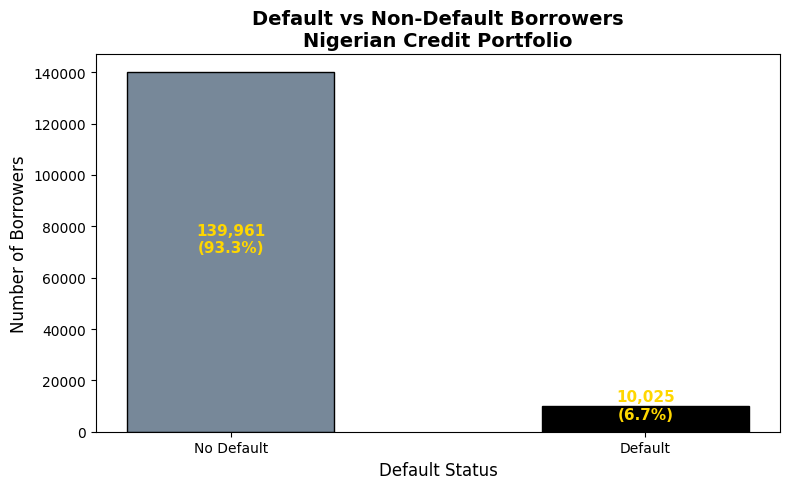

In [73]:
# EXPLORATORY DATA ANALYSIS (EDA)

# --- 1. Default Rate Distribution ---
plt.figure(figsize=(8, 5))

default_counts = df['DefaultStatus'].value_counts()
labels = ['No Default', 'Default']
colors = ['#778899', '#000']

plt.bar(labels, default_counts.values, color=colors, edgecolor='black', width=0.5)
plt.title('Default vs Non-Default Borrowers\nNigerian Credit Portfolio', fontsize=14, fontweight='bold')
plt.xlabel('Default Status', fontsize=12)
plt.ylabel('Number of Borrowers', fontsize=12)

# Add value labels on bars
for i, v in enumerate(default_counts.values):
    plt.text(i, v / 2, f'{v:,}\n({v/len(df)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold', color='gold')

plt.tight_layout()
plt.savefig('../reports/default_distribution.png', dpi=150)
plt.show()

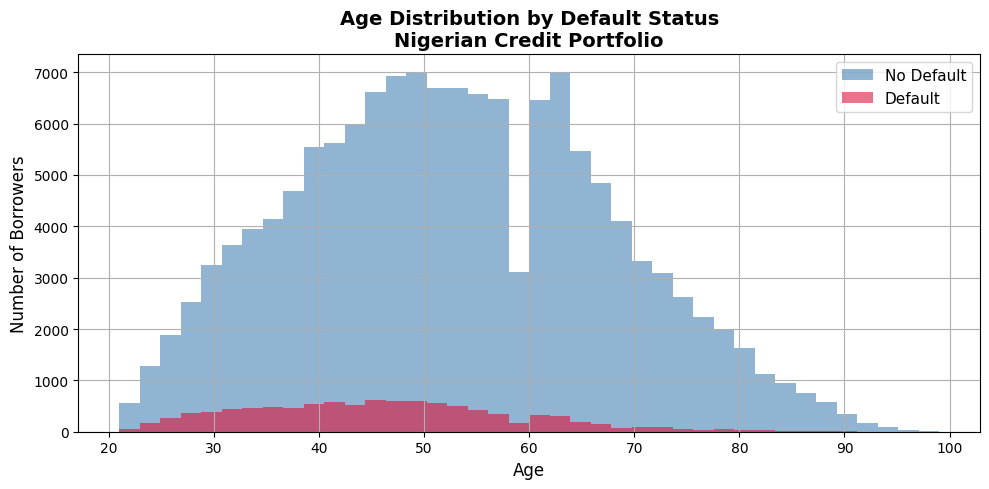

In [74]:
# --- 2. Age Distribution by Default Status ---
plt.figure(figsize=(10, 5))

df[df['DefaultStatus'] == 0]['Age'].hist(bins=40, alpha=0.6, 
                                          color='steelblue', 
                                          label='No Default')
df[df['DefaultStatus'] == 1]['Age'].hist(bins=40, alpha=0.6, 
                                          color='crimson', 
                                          label='Default')

plt.title('Age Distribution by Default Status\nNigerian Credit Portfolio', 
          fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Borrowers', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../reports/age_distribution.png', dpi=150)
plt.show()

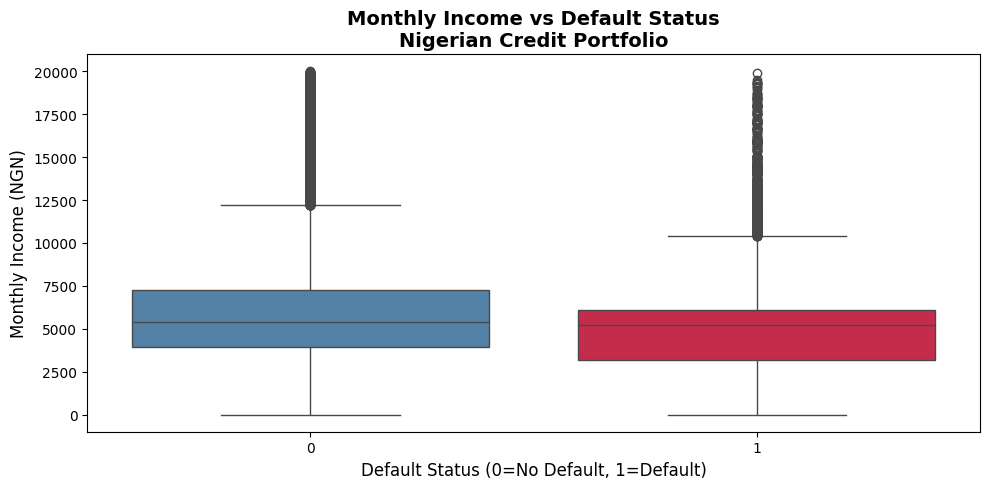

In [75]:
# --- 3. Monthly Income vs Default Status ---
plt.figure(figsize=(10, 5))

sns.boxplot(x='DefaultStatus', y='MonthlyIncome_NGN', 
            data=df[df['MonthlyIncome_NGN'] < 20000],
            hue='DefaultStatus',
            palette={0: 'steelblue', 1: 'crimson'},
            legend=False)

plt.title('Monthly Income vs Default Status\nNigerian Credit Portfolio', 
          fontsize=14, fontweight='bold')
plt.xlabel('Default Status (0=No Default, 1=Default)', fontsize=12)
plt.ylabel('Monthly Income (NGN)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/income_vs_default.png', dpi=150)
plt.show()

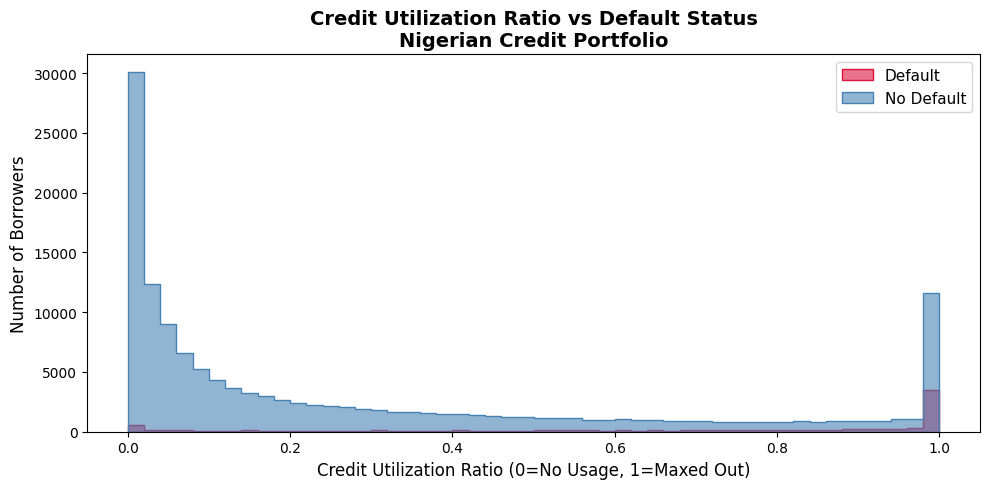

Credit Utilization chart has been saved!


In [76]:
# --- 4. Credit Utilization vs Default Status ---
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='CreditUtilizationRatio', 
             hue='DefaultStatus', 
             bins=50, 
             palette={0: 'steelblue', 1: 'crimson'},
             alpha=0.6,
             element='step')

plt.title('Credit Utilization Ratio vs Default Status\nNigerian Credit Portfolio', 
          fontsize=14, fontweight='bold')
plt.xlabel('Credit Utilization Ratio (0=No Usage, 1=Maxed Out)', fontsize=12)
plt.ylabel('Number of Borrowers', fontsize=12)
plt.legend(labels=['Default', 'No Default'], fontsize=11)
plt.tight_layout()
plt.savefig('../reports/credit_utilization.png', dpi=150)
plt.show()

print("Credit Utilization chart has been saved!")

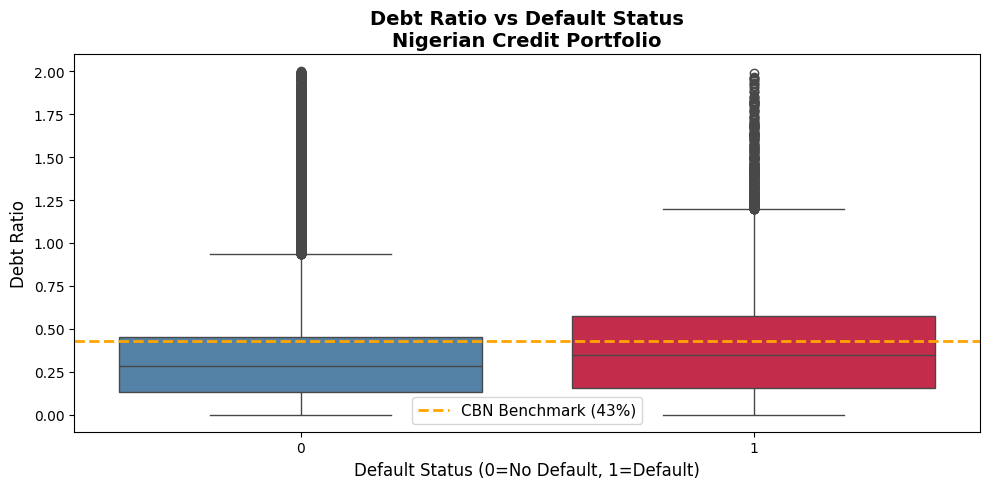

In [77]:
# --- 5. Debt Ratio vs Default Status ---
plt.figure(figsize=(10, 5))

# Filter extreme values for cleaner visualization
df_filtered = df[df['DebtRatio'] < 2]

sns.boxplot(x='DefaultStatus', y='DebtRatio',
            data=df_filtered,
            hue='DefaultStatus',
            palette={0: 'steelblue', 1: 'crimson'},
            legend=False)

plt.title('Debt Ratio vs Default Status\nNigerian Credit Portfolio',
          fontsize=14, fontweight='bold')
plt.xlabel('Default Status (0=No Default, 1=Default)', fontsize=12)
plt.ylabel('Debt Ratio', fontsize=12)

# Add a reference line at 0.43 (CBN benchmark)
plt.axhline(y=0.43, color='orange', linestyle='--', 
            linewidth=2, label='CBN Benchmark (43%)')
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/debt_ratio_vs_default.png', dpi=150)
plt.show()

In [78]:
# FEATURE ENGINEERING

# --- 1. Total Late Payments ---
df['TotalLatePayments'] = (df['DaysLate_30_59'] + 
                           df['DaysLate_60_89'] + 
                           df['DaysLate_90Plus'])

# --- 2. Actual Monthly Debt Burden in Naira ---
df['MonthlyDebtBurden_NGN'] = df['DebtRatio'] * df['MonthlyIncome_NGN']
df['MonthlyDebtBurden_Formatted'] = df['MonthlyDebtBurden_NGN'].apply(lambda x: f'₦{x:,.2f}')

# --- 3. Age Groups ---
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[18, 30, 45, 60, 100],
                        labels=['Young (18-30)', 
                                'Middle (31-45)', 
                                'Senior (46-60)', 
                                'Elder (61+)'])

# --- 4. Income Groups ---
df['IncomeGroup'] = pd.cut(df['MonthlyIncome_NGN'],
                           bins=[0, 3000, 6000, 12000, float('inf')],
                           labels=['Low', 'Medium', 'High', 'Very High'])

# Confirm
print("New features created successfully!")
print("\nSample of engineered features:")
print(df[['CustomerID', 'TotalLatePayments', 
          'MonthlyDebtBurden_Formatted',
          'AgeGroup', 'IncomeGroup']].head(10))

New features created successfully!

Sample of engineered features:
  CustomerID  TotalLatePayments MonthlyDebtBurden_Formatted        AgeGroup  \
0  CUS-00001                  2                   ₦7,323.20  Middle (31-45)   
1  CUS-00002                  0                     ₦316.88  Middle (31-45)   
2  CUS-00003                  2                     ₦258.91  Middle (31-45)   
3  CUS-00004                  0                     ₦118.96   Young (18-30)   
4  CUS-00005                  1                   ₦1,584.98  Senior (46-60)   
5  CUS-00006                  0                   ₦1,314.62     Elder (61+)   
6  CUS-00007                  0              ₦26,886,816.00  Senior (46-60)   
7  CUS-00008                  0                     ₦734.79  Middle (31-45)   
8  CUS-00009                  0                 ₦248,400.00   Young (18-30)   
9  CUS-00010                  0                  ₦14,359.39  Senior (46-60)   

  IncomeGroup  
0        High  
1         Low  
2      Medium  

In [79]:
# --- View Complete Table with All Columns ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

df.head(20)

,CustomerID,DefaultStatus,CreditUtilizationRatio,Age,DaysLate_30_59,DebtRatio,MonthlyIncome_NGN,OpenCreditLinesAndLoans,DaysLate_90Plus,RealEstateLoans,DaysLate_60_89,FamilyDependents,MonthlyIncome_Formatted,TotalLatePayments,MonthlyDebtBurden_NGN,MonthlyDebtBurden_Formatted,AgeGroup,IncomeGroup
0,CUS-00001,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00,"₦9,120.00",2,7323.20,"₦7,323.20",Middle (31-45),High
1,CUS-00002,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00,"₦2,600.00",0,316.88,₦316.88,Middle (31-45),Low
2,CUS-00003,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00,"₦3,042.00",2,258.91,₦258.91,Middle (31-45),Medium
3,CUS-00004,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00,"₦3,300.00",0,118.96,₦118.96,Young (18-30),Medium
4,CUS-00005,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00,"₦63,588.00",1,1584.98,"₦1,584.98",Senior (46-60),Very High
5,CUS-00006,0,0.21,74,0,0.38,3500.00,3,0,1,0,1.00,"₦3,500.00",0,1314.62,"₦1,314.62",Elder (61+),Medium
6,CUS-00007,0,0.31,57,0,4979.04,5400.00,8,0,3,0,0.00,"₦5,400.00",0,26886816.00,"₦26,886,816.00",Senior (46-60),Medium
7,CUS-00008,0,0.75,39,0,0.21,3500.00,8,0,0,0,0.00,"₦3,500.00",0,734.79,₦734.79,Middle (31-45),Medium
8,CUS-00009,0,0.12,27,0,46.00,5400.00,2,0,0,0,0.00,"₦5,400.00",0,248400.00,"₦248,400.00",Young (18-30),Medium
9,CUS-00010,0,0.19,57,0,0.61,23684.00,9,0,4,0,2.00,"₦23,684.00",0,14359.39,"₦14,359.39",Senior (46-60),Very High


In [80]:
# --- 5. Raw Risk Score ---
# Weighted scoring based on banking domain knowledge

df['RiskScore_Raw'] = (
    (df['CreditUtilizationRatio'] * 35) +   # 35% weight
    (df['TotalLatePayments'] * 20) +          # 20% weight
    (df['DebtRatio'] * 25) +                  # 25% weight
    (df['DaysLate_90Plus'] * 15) +            # 15% weight
    ((1 - (df['MonthlyIncome_NGN'] /          
     df['MonthlyIncome_NGN'].max())) * 5)     # 5% weight
)

# Normalize score to 0-100 scale
df['RiskScore'] = ((df['RiskScore_Raw'] - df['RiskScore_Raw'].min()) /
                   (df['RiskScore_Raw'].max() - df['RiskScore_Raw'].min()) * 100)

# Round to 2 decimal places
df['RiskScore'] = df['RiskScore'].round(2)

# Preview
print("\nSample Risk Scores:")
print(df[['CustomerID', 'DefaultStatus', 
          'RiskScore']].head(20))
print("\nRisk Score Statistics:")
print(df['RiskScore'].describe())


Sample Risk Scores:
   CustomerID  DefaultStatus  RiskScore
0   CUS-00001              1       0.07
1   CUS-00002              0       0.03
2   CUS-00003              0       0.07
3   CUS-00004              0       0.01
4   CUS-00005              0       0.05
5   CUS-00006              0       0.02
6   CUS-00007              0      99.72
7   CUS-00008              0       0.03
8   CUS-00009              0       0.93
9   CUS-00010              0       0.02
10  CUS-00011              0       0.03
11  CUS-00012              0       0.01
12  CUS-00013              0       0.01
13  CUS-00014              1       0.19
14  CUS-00015              0       9.56
15  CUS-00016              0       0.02
16  CUS-00017              0      41.22
17  CUS-00018              0       0.01
18  CUS-00019              0       0.02
19  CUS-00020              0       0.02

Risk Score Statistics:
count   149986.00
mean         6.37
std         18.16
min          0.00
25%          0.01
50%          0.03
75%    

In [81]:
# --- 6. Add Risk Level Column ---

def assign_risk_level(score):
    if score <= 20:
        return 'Low Risk'
    elif score <= 40:
        return 'Moderate Risk'
    elif score <= 60:
        return 'High Risk'
    elif score <= 80:
        return 'Very High Risk'
    else:
        return 'Extreme Risk'

df['RiskLevel'] = df['RiskScore'].apply(assign_risk_level)

# Preview side by side
print("Risk Score and Risk Level:")
print(df[['CustomerID', 'DefaultStatus', 
          'RiskScore', 'RiskLevel']].head(21))

# Distribution of risk levels
print("\nRisk Level Distribution:")
print(df['RiskLevel'].value_counts())

Risk Score and Risk Level:
   CustomerID  DefaultStatus  RiskScore  RiskLevel
0   CUS-00001              1       0.07   Low Risk
1   CUS-00002              0       0.03   Low Risk
2   CUS-00003              0       0.07   Low Risk
3   CUS-00004              0       0.01   Low Risk
4   CUS-00005              0       0.05   Low Risk
..        ...            ...        ...        ...
16  CUS-00017              0      41.22  High Risk
17  CUS-00018              0       0.01   Low Risk
18  CUS-00019              0       0.02   Low Risk
19  CUS-00020              0       0.02   Low Risk
20  CUS-00021              0       0.02   Low Risk

[21 rows x 4 columns]

Risk Level Distribution:
RiskLevel
Low Risk          133079
Moderate Risk       6925
High Risk           4731
Extreme Risk        2747
Very High Risk      2504
Name: count, dtype: int64


In [82]:
# --- 7. CBN Risk Band Classification ---

def assign_cbn_band(score):
    if score <= 20:
        return 'Performing'
    elif score <= 40:
        return 'Watch'
    elif score <= 60:
        return 'Substandard'
    elif score <= 80:
        return 'Doubtful'
    else:
        return 'Loss'

df['CBN_RiskBand'] = df['RiskScore'].apply(assign_cbn_band)

# Preview
print("CBN Risk Band Classification:")
print(df[['CustomerID', 'RiskScore', 
          'RiskLevel', 'CBN_RiskBand']].head(20))

# Distribution
print("\nCBN Risk Band Distribution:")
print(df['CBN_RiskBand'].value_counts())

CBN Risk Band Classification:
   CustomerID  RiskScore     RiskLevel CBN_RiskBand
0   CUS-00001       0.07      Low Risk   Performing
1   CUS-00002       0.03      Low Risk   Performing
2   CUS-00003       0.07      Low Risk   Performing
3   CUS-00004       0.01      Low Risk   Performing
4   CUS-00005       0.05      Low Risk   Performing
5   CUS-00006       0.02      Low Risk   Performing
6   CUS-00007      99.72  Extreme Risk         Loss
7   CUS-00008       0.03      Low Risk   Performing
8   CUS-00009       0.93      Low Risk   Performing
9   CUS-00010       0.02      Low Risk   Performing
10  CUS-00011       0.03      Low Risk   Performing
11  CUS-00012       0.01      Low Risk   Performing
12  CUS-00013       0.01      Low Risk   Performing
13  CUS-00014       0.19      Low Risk   Performing
14  CUS-00015       9.56      Low Risk   Performing
15  CUS-00016       0.02      Low Risk   Performing
16  CUS-00017      41.22     High Risk  Substandard
17  CUS-00018       0.01      Low 

In [83]:
print("Complete Feature List:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print(f"\nTotal columns: {len(df.columns)}")
print(f"Total borrowers: {len(df):,}")

Complete Feature List:
1. CustomerID
2. DefaultStatus
3. CreditUtilizationRatio
4. Age
5. DaysLate_30_59
6. DebtRatio
7. MonthlyIncome_NGN
8. OpenCreditLinesAndLoans
9. DaysLate_90Plus
10. RealEstateLoans
11. DaysLate_60_89
12. FamilyDependents
13. MonthlyIncome_Formatted
14. TotalLatePayments
15. MonthlyDebtBurden_NGN
16. MonthlyDebtBurden_Formatted
17. AgeGroup
18. IncomeGroup
19. RiskScore_Raw
20. RiskScore
21. RiskLevel
22. CBN_RiskBand

Total columns: 22
Total borrowers: 149,986


In [84]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

df.head(10)

,CustomerID,DefaultStatus,CreditUtilizationRatio,Age,DaysLate_30_59,DebtRatio,MonthlyIncome_NGN,OpenCreditLinesAndLoans,DaysLate_90Plus,RealEstateLoans,DaysLate_60_89,FamilyDependents,MonthlyIncome_Formatted,TotalLatePayments,MonthlyDebtBurden_NGN,MonthlyDebtBurden_Formatted,AgeGroup,IncomeGroup,RiskScore_Raw,RiskScore,RiskLevel,CBN_RiskBand
0,CUS-00001,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00,"₦9,120.00",2,7323.20,"₦7,323.20",Middle (31-45),High,91.87,0.07,Low Risk,Performing
1,CUS-00002,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00,"₦2,600.00",0,316.88,₦316.88,Middle (31-45),Low,41.54,0.03,Low Risk,Performing
2,CUS-00003,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00,"₦3,042.00",2,258.91,₦258.91,Middle (31-45),Medium,85.16,0.07,Low Risk,Performing
3,CUS-00004,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00,"₦3,300.00",0,118.96,₦118.96,Young (18-30),Medium,14.08,0.01,Low Risk,Performing
4,CUS-00005,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00,"₦63,588.00",1,1584.98,"₦1,584.98",Senior (46-60),Very High,57.27,0.05,Low Risk,Performing
5,CUS-00006,0,0.21,74,0,0.38,3500.00,3,0,1,0,1.00,"₦3,500.00",0,1314.62,"₦1,314.62",Elder (61+),Medium,21.85,0.02,Low Risk,Performing
6,CUS-00007,0,0.31,57,0,4979.04,5400.00,8,0,3,0,0.00,"₦5,400.00",0,26886816.00,"₦26,886,816.00",Senior (46-60),Medium,124491.69,99.72,Extreme Risk,Loss
7,CUS-00008,0,0.75,39,0,0.21,3500.00,8,0,0,0,0.00,"₦3,500.00",0,734.79,₦734.79,Middle (31-45),Medium,36.65,0.03,Low Risk,Performing
8,CUS-00009,0,0.12,27,0,46.00,5400.00,2,0,0,0,0.00,"₦5,400.00",0,248400.00,"₦248,400.00",Young (18-30),Medium,1159.08,0.93,Low Risk,Performing
9,CUS-00010,0,0.19,57,0,0.61,23684.00,9,0,4,0,2.00,"₦23,684.00",0,14359.39,"₦14,359.39",Senior (46-60),Very High,26.74,0.02,Low Risk,Performing


In [85]:
# --- Code To Save Engineered Dataset ---
df.to_csv('../data/credit_risk_engineered.csv', index=False)

print("Dataset saved successfully!")
print("Location: Credit Risk Project → data → credit_risk_engineered.csv")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

Dataset saved successfully!
Location: Credit Risk Project → data → credit_risk_engineered.csv
Total rows: 149,986
Total columns: 22


In [86]:
# CREDIT SCORECARD MODEL
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score)
from sklearn.preprocessing import StandardScaler

In [87]:
# ============================================
# PREPARE DATA FOR MODELLING
# ============================================

# --- Select Features for Model ---
features = [
    'CreditUtilizationRatio',
    'TotalLatePayments',
    'DebtRatio',
    'DaysLate_90Plus',
    'MonthlyIncome_NGN',
    'OpenCreditLinesAndLoans',
    'RealEstateLoans',
    'FamilyDependents',
    'RiskScore'
]

# --- Define X (inputs) and y (target) ---
X = df[features]
y = df['DefaultStatus']

# --- Split Data 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# --- Scale Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Confirm
print("Data preparation complete!")
print(f"Training set: {X_train.shape[0]:,} borrowers")
print(f"Testing set: {X_test.shape[0]:,} borrowers")
print(f"Default rate in training: {y_train.mean()*100:.1f}%")
print(f"Default rate in testing: {y_test.mean()*100:.1f}%")

Data preparation complete!
Training set: 119,988 borrowers
Testing set: 29,998 borrowers
Default rate in training: 6.7%
Default rate in testing: 6.7%


In [88]:
# ============================================
# BUILD & TRAIN THE MODEL
# ============================================

# --- Handle Class Imbalance ---
# class_weight='balanced' tells the model to pay more 
# attention to the rare default cases (6.7%)
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# --- Train the Model ---
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Training features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]:,}")

Model trained successfully!
Training features: 9
Training samples: 119,988


In [89]:
# ============================================
# EVALUATE THE MODEL
# ============================================

# --- Make Predictions ---
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# --- Classification Report ---
print("MODEL PERFORMANCE REPORT")
print("=" * 100)
print(classification_report(y_test, y_pred, 
      target_names=['No Default', 'Default']))

# --- ROC AUC Score ---
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"True Negatives  (Correctly predicted No Default): {cm[0][0]:,}")
print(f"False Positives (Wrongly flagged as Default):     {cm[0][1]:,}")
print(f"False Negatives (Missed actual Defaults):         {cm[1][0]:,}")
print(f"True Positives  (Correctly predicted Default):    {cm[1][1]:,}")

MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

  No Default       0.98      0.76      0.86     27993
     Default       0.18      0.74      0.29      2005

    accuracy                           0.76     29998
   macro avg       0.58      0.75      0.57     29998
weighted avg       0.92      0.76      0.82     29998

ROC AUC Score: 0.8311

Confusion Matrix:
True Negatives  (Correctly predicted No Default): 21,386
False Positives (Wrongly flagged as Default):     6,607
False Negatives (Missed actual Defaults):         529
True Positives  (Correctly predicted Default):    1,476


In [90]:
# ============================================
# ADD PREDICTIONS TO DATASET
# ============================================

# --- Scale full dataset ---
X_full = df[features]
X_full_scaled = scaler.transform(X_full)

# --- Generate predictions for all borrowers ---
df['Default_Predicted'] = model.predict(X_full_scaled)
df['Default_Probability'] = model.predict_proba(X_full_scaled)[:, 1]

# --- Round probability to 4 decimal places ---
df['Default_Probability'] = df['Default_Probability'].round(4)

# --- Add probability percentage for readability ---
df['Default_Probability_PCT'] = (df['Default_Probability'] * 100).round(2)

# Preview
print("\nSample Predictions:")
print(df[['CustomerID', 'DefaultStatus', 
          'RiskScore', 'CBN_RiskBand',
          'Default_Predicted',
          'Default_Probability_PCT']].head(15))


Sample Predictions:
   CustomerID  DefaultStatus  RiskScore CBN_RiskBand  Default_Predicted  \
0   CUS-00001              1       0.07   Performing                  1   
1   CUS-00002              0       0.03   Performing                  1   
2   CUS-00003              0       0.07   Performing                  1   
3   CUS-00004              0       0.01   Performing                  0   
4   CUS-00005              0       0.05   Performing                  0   
..        ...            ...        ...          ...                ...   
10  CUS-00011              0       0.03   Performing                  1   
11  CUS-00012              0       0.01   Performing                  0   
12  CUS-00013              0       0.01   Performing                  0   
13  CUS-00014              1       0.19   Performing                  1   
14  CUS-00015              0       9.56   Performing                  0   

    Default_Probability_PCT  
0                     82.17  
1                 

In [91]:
# --- Add Prediction Result Column ---
# --- This column tells us if it's Negative or Positive ---

def assign_prediction_result(row):
    actual = row['DefaultStatus']
    predicted = row['Default_Predicted']
    
    if actual == 0 and predicted == 0:
        return 'True Negative'
    elif actual == 0 and predicted == 1:
        return 'False Positive'
    elif actual == 1 and predicted == 0:
        return 'False Negative'
    else:
        return 'True Positive'

df['Prediction_Result'] = df.apply(assign_prediction_result, axis=1)

# Preview
print("Prediction Result column added!")
print("\nSample:")
print(df[['CustomerID', 'DefaultStatus', 
          'Default_Predicted',
          'Default_Probability_PCT',
          'Prediction_Result']].head(15))

# Distribution
print("\nPrediction Result Distribution:")
print(df['Prediction_Result'].value_counts())

Prediction Result column added!

Sample:
   CustomerID  DefaultStatus  Default_Predicted  Default_Probability_PCT  \
0   CUS-00001              1                  1                    82.17   
1   CUS-00002              0                  1                    71.61   
2   CUS-00003              0                  1                    59.97   
3   CUS-00004              0                  0                    26.54   
4   CUS-00005              0                  0                    42.57   
..        ...            ...                ...                      ...   
10  CUS-00011              0                  1                    51.59   
11  CUS-00012              0                  0                    22.30   
12  CUS-00013              0                  0                    22.43   
13  CUS-00014              1                  1                    91.52   
14  CUS-00015              0                  0                    19.38   

   Prediction_Result  
0      True Positive  


In [92]:
# --- Save Complete Final Dataset ---
df.to_csv('../data/credit_risk_final.csv', index=False)

print("Complete final dataset saved!")
print(f"Total columns: {len(df.columns)}")
print(f"Total borrowers: {len(df):,}")

Complete final dataset saved!
Total columns: 26
Total borrowers: 149,986


In [93]:
# ============================================
# SQLITE DATABASE INTEGRATION/CREATION
# ============================================

import sqlite3

# --- Create Database Connection ---
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()

print("SQLite database created successfully!")
print("Location: Credit Risk Project → data → credit_risk.db")

SQLite database created successfully!
Location: Credit Risk Project → data → credit_risk.db


In [94]:
# --- Load Dataset into SQLite ---
df.to_sql('loan_records', 
          conn, 
          if_exists='replace', 
          index=False)

print("Dataset loaded into SQLite successfully!")

# --- Verify it worked ---
cursor.execute("SELECT COUNT(*) FROM loan_records")
count = cursor.fetchone()[0]
print(f"Total records in database: {count:,}")

# --- Check table structure ---
cursor.execute("PRAGMA table_info(loan_records)")
columns = cursor.fetchall()
print(f"\nTotal columns in table: {len(columns)}")
print("\nDatabase columns:")
for col in columns:
    print(f"  {col[1]} — {col[2]}")

Dataset loaded into SQLite successfully!
Total records in database: 149,986

Total columns in table: 26

Database columns:
  CustomerID — TEXT
  DefaultStatus — INTEGER
  CreditUtilizationRatio — REAL
  Age — INTEGER
  DaysLate_30_59 — INTEGER
  DebtRatio — REAL
  MonthlyIncome_NGN — REAL
  OpenCreditLinesAndLoans — INTEGER
  DaysLate_90Plus — INTEGER
  RealEstateLoans — INTEGER
  DaysLate_60_89 — INTEGER
  FamilyDependents — REAL
  MonthlyIncome_Formatted — TEXT
  TotalLatePayments — INTEGER
  MonthlyDebtBurden_NGN — REAL
  MonthlyDebtBurden_Formatted — TEXT
  AgeGroup — TEXT
  IncomeGroup — TEXT
  RiskScore_Raw — REAL
  RiskScore — REAL
  RiskLevel — TEXT
  CBN_RiskBand — TEXT
  Default_Predicted — INTEGER
  Default_Probability — REAL
  Default_Probability_PCT — REAL
  Prediction_Result — TEXT


In [95]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [96]:
# SQL RISK QUERIES
# ============================================

# --- Query 1: High Risk Borrowers ---
# INSIGHT: Identify the most dangerous borrowers in our portfolio
# ranked by risk score. These are the customers that need
# immediate attention from the risk team. In a real Nigerian bank
# this list would land on the risk manager's desk every morning.

query1 = """
SELECT 
    CustomerID,
    Age,
    MonthlyIncome_NGN,
    RiskScore,
    RiskLevel,
    CBN_RiskBand,
    Default_Probability_PCT,
    Prediction_Result
FROM loan_records
WHERE RiskLevel IN ('High Risk', 'Very High Risk', 'Extreme Risk')
ORDER BY RiskScore DESC
LIMIT 20
"""

high_risk = pd.read_sql_query(query1, conn)
print("QUERY 1: Top 20 High Risk Borrowers")
print("=" * 50)
print(high_risk)
print(f"\nTotal high risk borrowers in portfolio: {len(pd.read_sql_query('SELECT * FROM loan_records WHERE RiskLevel IN (\"High Risk\", \"Very High Risk\", \"Extreme Risk\")', conn)):,}")

QUERY 1: Top 20 High Risk Borrowers
    CustomerID  Age  MonthlyIncome_NGN  RiskScore     RiskLevel CBN_RiskBand  \
0   CUS-118409   63            5400.00     100.00  Extreme Risk         Loss   
1   CUS-104001   65            5400.00      99.96  Extreme Risk         Loss   
2   CUS-116772   43            5400.00      99.92  Extreme Risk         Loss   
3    CUS-42104   54            5400.00      99.91  Extreme Risk         Loss   
4    CUS-25088   46               0.00      99.90  Extreme Risk         Loss   
..         ...  ...                ...        ...           ...          ...   
15   CUS-81879   53            5400.00      99.84  Extreme Risk         Loss   
16  CUS-149764   33            5400.00      99.84  Extreme Risk         Loss   
17   CUS-07660   49            5400.00      99.83  Extreme Risk         Loss   
18   CUS-56817   60            5400.00      99.83  Extreme Risk         Loss   
19   CUS-06296   62            5400.00      99.82  Extreme Risk         Loss   

   

In [97]:
# --- Query 2: CBN Risk Band Portfolio Summary ---
# INSIGHT: Get a proper view of the entire loan portfolio
# health using official CBN classification language.
# This is the exact report that goes to the Chief Risk Officer
# (CRO) and CBN examiners during regulatory audits. It shows
# how much of the portfolio is healthy vs deteriorating vs lost.

query2 = """
SELECT 
    CBN_RiskBand,
    COUNT(*) as Total_Borrowers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM loan_records), 2) as Portfolio_PCT,
    ROUND(AVG(RiskScore), 2) as Avg_RiskScore,
    ROUND(AVG(MonthlyIncome_NGN), 2) as Avg_Monthly_Income,
    ROUND(AVG(Default_Probability_PCT), 2) as Avg_Default_Probability,
    SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) as Actual_Defaults,
    ROUND(AVG(DebtRatio), 4) as Avg_DebtRatio
FROM loan_records
GROUP BY CBN_RiskBand
ORDER BY 
    CASE CBN_RiskBand
        WHEN 'Performing' THEN 1
        WHEN 'Watch' THEN 2
        WHEN 'Substandard' THEN 3
        WHEN 'Doubtful' THEN 4
        WHEN 'Loss' THEN 5
    END
"""

cbn_summary = pd.read_sql_query(query2, conn)
print("QUERY 2: CBN Risk Band Portfolio Summary")
print("=" * 50)
print(cbn_summary.to_string(index=False))

QUERY 2: CBN Risk Band Portfolio Summary
CBN_RiskBand  Total_Borrowers  Portfolio_PCT  Avg_RiskScore  Avg_Monthly_Income  Avg_Default_Probability  Actual_Defaults  Avg_DebtRatio
  Performing           133079          88.73           0.64             6588.71                    38.29             9195          30.31
       Watch             6925           4.62          29.75             5014.81                    30.54              321        1484.61
 Substandard             4731           3.15          49.08             5111.23                    31.76              200        2449.90
    Doubtful             2504           1.67          68.67             5160.63                    32.63              126        3428.07
        Loss             2747           1.83          94.71             5118.90                    35.92              183        4728.17


In [98]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [99]:
# --- Query 3: Age Group Default Patterns ---
# INSIGHT: Identify which age groups carry the highest default
# risk in our portfolio. This helps the bank make age-informed
# lending decisions and design targeted loan products for
# different life stages. For example a bank might offer
# stricter collateral requirements for younger borrowers
# who show higher default tendencies.

query3 = """
SELECT 
    AgeGroup,
    COUNT(*) as Total_Borrowers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM loan_records), 2) as Portfolio_PCT,
    SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) as Actual_Defaults,
    ROUND(SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Default_Rate_PCT,
    ROUND(AVG(RiskScore), 2) as Avg_RiskScore,
    ROUND(AVG(MonthlyIncome_NGN), 2) as Avg_Income,
    ROUND(AVG(DebtRatio), 4) as Avg_DebtRatio,
    ROUND(AVG(Default_Probability_PCT), 2) as Avg_Default_Probability
FROM loan_records
GROUP BY AgeGroup
ORDER BY Default_Rate_PCT DESC
"""

age_summary = pd.read_sql_query(query3, conn)
print("QUERY 3: Age Group Default Patterns")
print("=" * 50)
print(age_summary.to_string(index=False))

QUERY 3: Age Group Default Patterns
      AgeGroup  Total_Borrowers  Portfolio_PCT  Actual_Defaults  Default_Rate_PCT  Avg_RiskScore  Avg_Income  Avg_DebtRatio  Avg_Default_Probability
 Young (18-30)            10757           7.17             1244             11.56           2.00     3568.60          94.22                    46.12
Middle (31-45)            40547          27.03             3775              9.31           5.43     6205.47         269.51                    42.92
Senior (46-60)            53635          35.76             3657              6.82           7.67     7221.98         381.47                    38.53
   Elder (61+)            45047          30.03             1349              2.99           6.72     6334.72         334.67                    29.62


In [100]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [101]:
# --- Query 4: Income Group Analysis ---
# INSIGHT: Understand how income levels affect loan performance
# across our portfolio. This query helps the bank set
# income-based lending limits and design appropriate loan
# products for each income segment. In Nigerian banking,
# income segmentation directly determines loan eligibility,
# maximum loan amounts and interest rate tiers offered
# to different customer groups.

query4 = """
SELECT 
    IncomeGroup,
    COUNT(*) as Total_Borrowers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM loan_records), 2) as Portfolio_PCT,
    SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) as Actual_Defaults,
    ROUND(SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Default_Rate_PCT,
    ROUND(AVG(RiskScore), 2) as Avg_RiskScore,
    ROUND(AVG(MonthlyIncome_NGN), 2) as Avg_Income,
    ROUND(AVG(CreditUtilizationRatio), 4) as Avg_CreditUtilization,
    ROUND(AVG(TotalLatePayments), 2) as Avg_LatePayments,
    ROUND(AVG(Default_Probability_PCT), 2) as Avg_Default_Probability
FROM loan_records
GROUP BY IncomeGroup
ORDER BY 
    CASE IncomeGroup
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
        WHEN 'Very High' THEN 4
    END
"""

income_summary = pd.read_sql_query(query4, conn)
print("QUERY 4: Income Group Analysis")
print("=" * 50)
print(income_summary.to_string(index=False))

QUERY 4: Income Group Analysis
IncomeGroup  Total_Borrowers  Portfolio_PCT  Actual_Defaults  Default_Rate_PCT  Avg_RiskScore  Avg_Income  Avg_CreditUtilization  Avg_LatePayments  Avg_Default_Probability
        NaN             1634           1.09               66              4.04          27.39        0.00                   0.30              1.55                    35.39
        Low            23446          15.63             2210              9.43           0.50     2016.12                   0.40              1.74                    42.53
     Medium            73711          49.15             5123              6.95          12.18     4873.46                   0.32              1.01                    36.71
       High            40453          26.97             2137              5.28           0.03     8396.05                   0.29              0.43                    37.16
  Very High            10742           7.16              489              4.55           0.02    20160.96    

In [102]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [103]:
# --- Query 5: Overdue Loan Detection ---
# INSIGHT: Identify borrowers who are already showing signs
# of serious delinquency — specifically those with 90+ days
# late payments combined with high default probability.
# This is the EXACT query that feeds our automated email
# alert system. In Nigerian banks this list is generated
# every morning and sent to relationship managers and
# the risk team for immediate intervention before loans
# deteriorate further into the Loss category.

query5 = """
SELECT 
    CustomerID,
    Age,
    AgeGroup,
    MonthlyIncome_Formatted,
    TotalLatePayments,
    DaysLate_90Plus,
    DebtRatio,
    RiskScore,
    RiskLevel,
    CBN_RiskBand,
    Default_Probability_PCT,
    Prediction_Result
FROM loan_records
WHERE DaysLate_90Plus >= 2
AND Default_Probability_PCT >= 50
AND CBN_RiskBand IN ('Substandard', 'Doubtful', 'Loss')
ORDER BY Default_Probability_PCT DESC, 
         DaysLate_90Plus DESC
LIMIT 30
"""

overdue_loans = pd.read_sql_query(query5, conn)
print("QUERY 5: High Risk Overdue Loans")
print("=" * 50)
print(f"Total overdue high risk borrowers flagged: {len(overdue_loans)}")
print("\nTop Overdue Borrowers:")
print(overdue_loans.to_string(index=False))

QUERY 5: High Risk Overdue Loans
Total overdue high risk borrowers flagged: 30

Top Overdue Borrowers:
CustomerID  Age       AgeGroup MonthlyIncome_Formatted  TotalLatePayments  DaysLate_90Plus  DebtRatio  RiskScore      RiskLevel CBN_RiskBand  Default_Probability_PCT Prediction_Result
 CUS-27564   37 Middle (31-45)               ₦5,400.00                 11                4    3506.00      70.47 Very High Risk     Doubtful                    96.62     True Positive
CUS-129684   59 Senior (46-60)               ₦5,400.00                 15                3    4793.00      96.28   Extreme Risk         Loss                    95.09     True Positive
CUS-129132   62    Elder (61+)               ₦5,400.00                 11                3    4437.00      89.10   Extreme Risk         Loss                    94.93    False Positive
 CUS-34231   49 Senior (46-60)               ₦5,400.00                 10                2    2953.00      59.35      High Risk  Substandard                    9

In [104]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [105]:
# --- Export Query Results for Power BI ---

# Save all query results as CSVs
cbn_summary.to_csv('../dashboard/cbn_portfolio_summary.csv', index=False)
age_summary.to_csv('../dashboard/age_group_analysis.csv', index=False)
income_summary.to_csv('../dashboard/income_group_analysis.csv', index=False)
overdue_loans.to_csv('../dashboard/overdue_loans.csv', index=False)
df.to_csv('../dashboard/full_loan_data.csv', index=False)

print("All datasets exported for Power BI!")
print("Location: Credit Risk Project → dashboard folder")

All datasets exported for Power BI!
Location: Credit Risk Project → dashboard folder


In [106]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")


Database connected successfully!


In [107]:
# --- Add Sort Order to CBN Summary ---
cbn_sort = {
    'Performing': 1,
    'Watch': 2,
    'Substandard': 3,
    'Doubtful': 4,
    'Loss': 5
}

cbn_portfolio_summary['CBN_Sort_Order'] = cbn_portfolio_summary['CBN_RiskBand'].map(cbn_sort)

# Re-export with sort order included
cbn_portfolio_summary.to_csv('../dashboard/cbn_portfolio_summary.csv', index=False)

print("CBN summary re-exported with sort order!")
print(cbn_portfolio_summary[['CBN_RiskBand', 'CBN_Sort_Order']])

NameError: name 'cbn_portfolio_summary' is not defined

In [ ]:
# --- Add Sort Order to CBN Summary ---
cbn_sort = {
    'Performing': 1,
    'Watch': 2,
    'Substandard': 3,
    'Doubtful': 4,
    'Loss': 5
}

cbn_summary['CBN_Sort_Order'] = cbn_summary['CBN_RiskBand'].map(cbn_sort)

# Re-export with sort order included
cbn_summary.to_csv('../dashboard/cbn_portfolio_summary.csv', index=False)

print("CBN summary re-exported with sort order!")
print(cbn_summary[['CBN_RiskBand', 'CBN_Sort_Order']])

In [ ]:
# --- Re-run Query 2 to recreate cbn_summary ---
query2 = """
SELECT 
    CBN_RiskBand,
    COUNT(*) as Total_Borrowers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM loan_records), 2) as Portfolio_PCT,
    ROUND(AVG(RiskScore), 2) as Avg_RiskScore,
    ROUND(AVG(MonthlyIncome_NGN), 2) as Avg_Monthly_Income,
    ROUND(AVG(Default_Probability_PCT), 2) as Avg_Default_Probability,
    SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) as Actual_Defaults,
    ROUND(AVG(DebtRatio), 4) as Avg_DebtRatio
FROM loan_records
GROUP BY CBN_RiskBand
ORDER BY 
    CASE CBN_RiskBand
        WHEN 'Performing' THEN 1
        WHEN 'Watch' THEN 2
        WHEN 'Substandard' THEN 3
        WHEN 'Doubtful' THEN 4
        WHEN 'Loss' THEN 5
    END
"""

cbn_summary = pd.read_sql_query(query2, conn)
print("cbn_summary recreated successfully!")

# --- Now add sort order ---
cbn_sort = {
    'Performing': 1,
    'Watch': 2,
    'Substandard': 3,
    'Doubtful': 4,
    'Loss': 5
}

cbn_summary['CBN_Sort_Order'] = cbn_summary['CBN_RiskBand'].map(cbn_sort)

# Re-export with sort order included
cbn_summary.to_csv('../dashboard/cbn_portfolio_summary.csv', index=False)

print("CBN summary re-exported with sort order!")
print(cbn_summary[['CBN_RiskBand', 'CBN_Sort_Order']])

In [ ]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

In [ ]:
# --- Re-run Query 2 to recreate cbn_summary ---
query2 = """
SELECT 
    CBN_RiskBand,
    COUNT(*) as Total_Borrowers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM loan_records), 2) as Portfolio_PCT,
    ROUND(AVG(RiskScore), 2) as Avg_RiskScore,
    ROUND(AVG(MonthlyIncome_NGN), 2) as Avg_Monthly_Income,
    ROUND(AVG(Default_Probability_PCT), 2) as Avg_Default_Probability,
    SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) as Actual_Defaults,
    ROUND(AVG(DebtRatio), 4) as Avg_DebtRatio
FROM loan_records
GROUP BY CBN_RiskBand
ORDER BY 
    CASE CBN_RiskBand
        WHEN 'Performing' THEN 1
        WHEN 'Watch' THEN 2
        WHEN 'Substandard' THEN 3
        WHEN 'Doubtful' THEN 4
        WHEN 'Loss' THEN 5
    END
"""

cbn_summary = pd.read_sql_query(query2, conn)
print("cbn_summary recreated successfully!")

# --- Now add sort order ---
cbn_sort = {
    'Performing': 1,
    'Watch': 2,
    'Substandard': 3,
    'Doubtful': 4,
    'Loss': 5
}

cbn_summary['CBN_Sort_Order'] = cbn_summary['CBN_RiskBand'].map(cbn_sort)

# Re-export with sort order included
cbn_summary.to_csv('../dashboard/cbn_portfolio_summary.csv', index=False)

print("CBN summary re-exported with sort order!")
print(cbn_summary[['CBN_RiskBand', 'CBN_Sort_Order']])

In [ ]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

In [ ]:
# --- Add Sort Order to Overdue Loans ---
overdue_sort = {
    'Substandard': 1,
    'Doubtful': 2,
    'Loss': 3
}

overdue_loans['CBN_Sort_Order'] = overdue_loans['CBN_RiskBand'].map(overdue_sort)

# Re-export
overdue_loans.to_csv('../dashboard/overdue_loans.csv', index=False)

print("Overdue loans re-exported with sort order!")

In [ ]:
print (overdue_sort)

In [ ]:
# --- Re-run Query 2 to recreate cbn_summary ---
query2 = """
SELECT 
    CBN_RiskBand,
    COUNT(*) as Total_Borrowers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM loan_records), 2) as Portfolio_PCT,
    ROUND(AVG(RiskScore), 2) as Avg_RiskScore,
    ROUND(AVG(MonthlyIncome_NGN), 2) as Avg_Monthly_Income,
    ROUND(AVG(Default_Probability_PCT), 2) as Avg_Default_Probability,
    SUM(CASE WHEN DefaultStatus = 1 THEN 1 ELSE 0 END) as Actual_Defaults,
    ROUND(AVG(DebtRatio), 4) as Avg_DebtRatio
FROM loan_records
GROUP BY CBN_RiskBand
ORDER BY 
    CASE CBN_RiskBand
        WHEN 'Performing' THEN 1
        WHEN 'Watch' THEN 2
        WHEN 'Substandard' THEN 3
        WHEN 'Doubtful' THEN 4
        WHEN 'Loss' THEN 5
    END
"""

cbn_summary = pd.read_sql_query(query2, conn)
print("cbn_summary recreated successfully!")

# --- Now add sort order ---
cbn_sort = {
    'Performing': 1,
    'Watch': 2,
    'Substandard': 3,
    'Doubtful': 4,
    'Loss': 5
}

cbn_summary['CBN_Sort_Order'] = cbn_summary['CBN_RiskBand'].map(cbn_sort)

# Re-export with sort order included
cbn_summary.to_csv('../dashboard/cbn_portfolio_summary.csv', index=False)

print("CBN summary re-exported with sort order!")
print(cbn_summary[['CBN_RiskBand', 'CBN_Sort_Order']])

In [109]:
# ============================================
# AUTOMATED EMAIL ALERT SYSTEM
# ============================================

import smtplib
import schedule
import time
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from datetime import datetime

print("Email alert libraries imported successfully!")

Email alert libraries imported successfully!


In [108]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [110]:
# ============================================
# STEP 1: FETCH HIGH RISK BORROWERS FROM DB
# ============================================

def get_high_risk_borrowers():
    """
    Queries SQLite database for high risk 
    and overdue borrowers that need immediate attention
    """
    
    query = """
    SELECT 
        CustomerID,
        Age,
        AgeGroup,
        MonthlyIncome_Formatted,
        TotalLatePayments,
        DaysLate_90Plus,
        RiskScore,
        RiskLevel,
        CBN_RiskBand,
        Default_Probability_PCT,
        Prediction_Result
    FROM loan_records
    WHERE DaysLate_90Plus >= 2
    AND Default_Probability_PCT >= 50
    AND CBN_RiskBand IN ('Substandard', 'Doubtful', 'Loss')
    ORDER BY Default_Probability_PCT DESC
    LIMIT 20
    """
    
    flagged = pd.read_sql_query(query, conn)
    return flagged

# --- Test it ---
flagged_borrowers = get_high_risk_borrowers()
print(f"High risk borrowers flagged: {len(flagged_borrowers)}")
print(flagged_borrowers[['CustomerID', 'RiskScore', 'RiskLevel',
                          'CBN_RiskBand', 
                          'Default_Probability_PCT']].head())

High risk borrowers flagged: 20
   CustomerID  RiskScore       RiskLevel CBN_RiskBand  Default_Probability_PCT
0   CUS-27564      70.47  Very High Risk     Doubtful                    96.62
1  CUS-129684      96.28    Extreme Risk         Loss                    95.09
2  CUS-129132      89.10    Extreme Risk         Loss                    94.93
3   CUS-34231      59.35       High Risk  Substandard                    93.87
4  CUS-118409     100.00    Extreme Risk         Loss                    93.62


In [111]:
print(len(flagged_borrowers))

20


In [112]:
# ============================================
# STEP 2: BUILD HTML EMAIL TEMPLATE
# ============================================

def build_email_body(flagged_df):
    """
    Builds a professional HTML email body
    with flagged borrower details
    """
    
    # --- Summary Statistics ---
    total_flagged = len(flagged_df)
    avg_risk_score = flagged_df['RiskScore'].mean().round(2)
    risk_level = flagged_df['RiskLevel']
    avg_default_prob = flagged_df['Default_Probability_PCT'].mean().round(2)
    highest_risk = flagged_df['RiskScore'].max()
    timestamp = datetime.now().strftime("%B %d, %Y at %I:%M %p")
    
    # --- Build HTML Table Rows ---
    table_rows = ""
    for _, row in flagged_df.iterrows():
        # Color code by CBN band
        if row['CBN_RiskBand'] == 'Loss':
            color = '#ff4444'
        elif row['CBN_RiskBand'] == 'Doubtful':
            color = '#ff8800'
        else:
            color = '#ffaa00'
            
        table_rows += f"""
        <tr>
            <td style="padding:8px;border:1px solid #ddd">{row['CustomerID']}</td>
            <td style="padding:8px;border:1px solid #ddd">{row['Age']}</td>
            <td style="padding:8px;border:1px solid #ddd">{row['MonthlyIncome_Formatted']}</td>
            <td style="padding:8px;border:1px solid #ddd">{row['DaysLate_90Plus']}</td>
            <td style="padding:8px;border:1px solid #ddd">{row['RiskScore']}</td>
            <td style="padding:8px;border:1px solid #ddd">{row['RiskLevel']}</td>
            <td style="padding:8px;border:1px solid #ddd; background-color:{color};color:white; font-weight:bold">{row['CBN_RiskBand']}</td>
            <td style="padding:8px;border:1px solid #ddd">{row['Default_Probability_PCT']}%</td>
        </tr>
        """
    
    # --- Build Full HTML Email ---
    html = f"""
    <html>
    <body style="font-family: Arial, sans-serif; margin:0; padding:20px; 
                 background-color:#f4f4f4;">
    
        <!-- Header -->
        <div style="background-color:#1a1a2e; padding:20px; 
                    border-radius:8px; margin-bottom:20px;">
            <h1 style="color:#f0a500; margin:0;">
                🚨 CREDIT RISK ALERT
            </h1>
            <p style="color:white; margin:5px 0 0 0;">
                Nigerian Credit Portfolio — Early Warning System
            </p>
            <p style="color:#aaa; margin:5px 0 0 0; font-size:12px;">
                Generated: {timestamp}
            </p>
        </div>
        
        <!-- Summary Cards -->
        <div style="display:flex; gap:15px; margin-bottom:20px;">
        
            <div style="background:white; padding:15px; 
                        border-radius:8px; flex:1; 
                        border-left:4px solid #ff4444;">
                <p style="margin:0; color:#666; font-size:12px;">
                    TOTAL FLAGGED
                </p>
                <h2 style="margin:5px 0; color:#ff4444;">
                    {total_flagged}
                </h2>
                <p style="margin:0; color:#666; font-size:12px;">
                    borrowers need attention
                </p>
            </div>
            
            <div style="background:white; padding:15px; 
                        border-radius:8px; flex:1;
                        border-left:4px solid #ff8800;">
                <p style="margin:0; color:#666; font-size:12px;">
                    AVG RISK SCORE
                </p>
                <h2 style="margin:5px 0; color:#ff8800;">
                    {avg_risk_score}
                </h2>
                <p style="margin:0; color:#666; font-size:12px;">
                    out of 100
                </p>
            </div>

          <!-- <div style="background:white; padding:15px; 
                        border-radius:8px; flex:1;
                        border-left:4px solid #ff8800;">
                <p style="margin:0; color:#666; font-size:12px;">
                    RISK LEVEL
                </p>
                <h2 style="margin:5px 0; color:#ff8800;">
                    {risk_level}
                </h2>
                <p style="margin:0; color:#666; font-size:12px;">
                    out of five risk levels
                </p>
            </div> -->
            
            <div style="background:white; padding:15px; 
                        border-radius:8px; flex:1;
                        border-left:4px solid #cc0000;">
                <p style="margin:0; color:#666; font-size:12px;">
                    AVG DEFAULT PROBABILITY
                </p>
                <h2 style="margin:5px 0; color:#cc0000;">
                    {avg_default_prob}%
                </h2>
                <p style="margin:0; color:#666; font-size:12px;">
                    model confidence
                </p>
            </div>
            
            <div style="background:white; padding:15px; 
                        border-radius:8px; flex:1;
                        border-left:4px solid #E61158;">
                <p style="margin:0; color:#666; font-size:12px;">
                    HIGHEST RISK SCORE
                </p>
                <h2 style="margin:5px 0; color:#E61158;">
                    {highest_risk}
                </h2>
                <p style="margin:0; color:#666; font-size:12px;">
                    maximum recorded
                </p>
            </div>
            
        </div>
        
        <!-- Alert Message -->
        <div style="background:#fff3cd; padding:15px; 
                    border-radius:8px; margin-bottom:20px;
                    border-left:4px solid #f0a500;">
            <p style="margin:0; color:#856404;">
                ⚠️ <strong>IMMEDIATE ACTION REQUIRED:</strong> 
                The following borrowers have been flagged by our 
                credit risk system based on 90+ days 
                delinquency, high default probability and deteriorated 
                CBN classification. Please initiate intervention 
                procedures immediately.
            </p>
        </div>
        
        <!-- Borrower Table -->
        <div style="background:white; padding:20px; 
                    border-radius:8px; margin-bottom:20px;">
            <h3 style="color:#1a1a2e; margin-top:0;">
                Flagged Borrowers — Detailed Report
            </h3>
            <table style="width:100%; border-collapse:collapse; 
                          font-size:13px;">
                <thead>
                    <tr style="background-color:#1a1a2e; color:white;">
                        <th style="padding:10px; text-align:left;">
                            Customer ID
                        </th>
                        <th style="padding:10px; text-align:left;">
                            Age
                        </th>
                        <th style="padding:10px; text-align:left;">
                            Monthly Income
                        </th>
                        <th style="padding:10px; text-align:left;">
                            Days 90+ Late
                        </th>
                        <th style="padding:10px; text-align:left;">
                            Risk Score
                        </th>
                        <th style="padding:10px; text-align:left;">
                            Risk Level
                        </th>
                        <th style="padding:10px; text-align:left;">
                            CBN Band
                        </th>
                        <th style="padding:10px; text-align:left;">
                            Default Probability
                        </th>
                    </tr>
                </thead>
                <tbody>
                    {table_rows}
                </tbody>
            </table>
        </div>
        
        <!-- Footer -->
        <div style="background:#1a1a2e; padding:15px; 
                    border-radius:8px; text-align:center;">
            <p style="color:#aaa; margin:0; font-size:12px;">
                This alert was automatically generated by the 
                Nigerian Credit Risk Scorecard System
            </p>
            <p style="color:#aaa; margin:5px 0 0 0; font-size:12px;">
                Powered by ML Model (AUC: 0.83) | 
                CBN Regulatory Framework | 
                Do not reply to this email
            </p>
        </div>
        
    </body>
    </html>
    """
    
    return html

# --- Test it ---
email_body = build_email_body(flagged_borrowers)
print("Email template built successfully!")
print(f"Email length: {len(email_body):,} characters")

Email template built successfully!
Email length: 19,838 characters


In [113]:
# --- Preview Email in Jupyter ---
from IPython.display import HTML

HTML(email_body)

Customer ID,Age,Monthly Income,Days 90+ Late,Risk Score,Risk Level,CBN Band,Default Probability
CUS-27564,37,"₦5,400.00",4,70.47,Very High Risk,Doubtful,96.62%
CUS-129684,59,"₦5,400.00",3,96.28,Extreme Risk,Loss,95.09%
CUS-129132,62,"₦5,400.00",3,89.1,Extreme Risk,Loss,94.93%
CUS-34231,49,"₦5,400.00",2,59.35,High Risk,Substandard,93.87%
CUS-118409,63,"₦5,400.00",7,100.0,Extreme Risk,Loss,93.62%
CUS-104001,65,"₦5,400.00",5,99.96,Extreme Risk,Loss,93.2%
CUS-11467,47,"₦5,400.00",5,64.42,Very High Risk,Doubtful,92.96%
CUS-116772,43,"₦5,400.00",3,99.92,Extreme Risk,Loss,92.91%
CUS-18169,42,"₦5,400.00",4,49.25,High Risk,Substandard,92.68%
CUS-101495,53,"₦5,400.00",2,49.5,High Risk,Substandard,92.04%


In [ ]:
import sqlite3
conn = sqlite3.connect('../data/credit_risk.db')
cursor = conn.cursor()
print("Database connected successfully!")

In [114]:
# ============================================
# STEP 3: EMAIL SENDING FUNCTION
# ============================================

def send_alert_email(receiver_email):
    """
    Sends the credit risk alert email
    to the specified receiver
    """
    
    # --- Email Configuration ---
    sender_email = "emmanuelchinonso1340@gmail.com"    
    sender_password = "pgkrzvnldsffzmpr"       
    subject = f"🚨 CREDIT RISK ALERT — {datetime.now().strftime('%B %d, %Y')} | Nigerian Portfolio"

    # --- Get fresh data ---
    flagged = get_high_risk_borrowers()
    
    # --- Check if any borrowers flagged ---
    if len(flagged) == 0:
        print("No high risk borrowers found today — no alert sent!")
        return
    
    # --- Build email ---
    msg = MIMEMultipart('alternative')
    msg['Subject'] = subject
    msg['From'] = sender_email
    msg['To'] = receiver_email
    
    # --- Attach HTML body ---
    html_body = build_email_body(flagged)
    msg.attach(MIMEText(html_body, 'html'))
    
    # --- Send email ---
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.sendmail(sender_email, receiver_email, msg.as_string())
        server.quit()
        print(f"Alert email sent successfully to {receiver_email}!")
        print(f"Total borrowers flagged: {len(flagged)}")
        print(f"Sent at: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
        
    except Exception as e:
        print(f"Email failed to send. Error: {str(e)}")

print("Email sending function created successfully!")

Email sending function created successfully!


In [ ]:
# ============================================
# STEP 4: AUTOMATED SCHEDULER
# ============================================

def run_daily_alert():
    """
    Main function that runs every day automatically
    """
    print(f"\n{'='*50}")
    print(f"Running Credit Risk Alert System...")
    print(f"Time: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
    print(f"{'='*50}")
    
    # --- Send alert to risk team ---
    send_alert_email("nonsoemmy4469@gmail.com") 

# --- Schedule to run every day at 8:00 AM ---
schedule.every().day.at("08:00").do(run_daily_alert)

print("Scheduler configured successfully!")
print("Alert will run every day at 8:00 AM")
print("\nRunning scheduler — press Ctrl+C to stop...")

# --- Keep scheduler running ---
while True:
    schedule.run_pending()
    time.sleep(60)

In [ ]:
# --- Test Mode: Run in 1 minute ---
import datetime as dt
run_time = (dt.datetime.now() + 
            dt.timedelta(minutes=1)).strftime("%H:%M")

schedule.every().day.at(run_time).do(run_daily_alert)

print(f"Test alert scheduled for: {run_time}")
print("Waiting... check your email in 1 minute! 📧")

while True:
    schedule.run_pending()
    time.sleep(60)

In [115]:
# --- Updated send function with port 465 ---
def send_alert_email(receiver_email):
    
    sender_email = "emmanuelchinonso1340@gmail.com"
    sender_password = "dmbzsbmvespfcmep"
    subject = f"CREDIT RISK ALERT — {datetime.now().strftime('%B %d, %Y')} | Nigerian Portfolio"

    flagged = get_high_risk_borrowers()
    
    if len(flagged) == 0:
        print("No high risk borrowers found!")
        return
    
    msg = MIMEMultipart('alternative')
    msg['Subject'] = subject
    msg['From'] = sender_email
    msg['To'] = receiver_email
    
    html_body = build_email_body(flagged)
    msg.attach(MIMEText(html_body, 'html'))
    
    try:
        # Using SSL on port 465 instead of TLS on 587
        server = smtplib.SMTP_SSL('smtp.gmail.com', 465)
        server.login(sender_email, sender_password)
        server.sendmail(sender_email, receiver_email, 
                       msg.as_string())
        server.quit()
        print(f"Alert email sent successfully!")
        print(f"Sent to: {receiver_email}")
        print(f"Borrowers flagged: {len(flagged)}")
        print(f"Time: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
        
    except Exception as e:
        print(f"Error: {str(e)}")

# --- Test immediately ---
send_alert_email("nonsoemmy4469@gmail.com")

Alert email sent successfully!
Sent to: nonsoemmy4469@gmail.com
Borrowers flagged: 20
Time: June 18, 2026 at 10:22 AM
